<a href="https://colab.research.google.com/github/srima231/Bank-Loan-Data-Analysis-Risk-Insights/blob/main/Banking_Loan_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [2]:
df=pd.read_excel("/content/financial_loan.xlsx")
df

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677


In [3]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [4]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


In [5]:
df.shape

(38576, 24)

In [6]:
df.dtypes

,0
id,int64
address_state,object
application_type,object
emp_length,object
emp_title,object
grade,object
home_ownership,object
issue_date,datetime64[ns]
last_credit_pull_date,datetime64[ns]
last_payment_date,datetime64[ns]


In [7]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


In [8]:
total_loan_application=df['id'].count()
print("Total Loan Application",total_loan_application)

Total Loan Application 38576


In [9]:
# Get Latest date
latest_issue_date=df['issue_date'].max() # 2021-12-31
# extract year and month
latest_year=latest_issue_date.year # 2021
latest_month=latest_issue_date.month # 12
# filter data for MTD
mtd_date=df[
    (df['issue_date'].dt.year==latest_year)&
    (df['issue_date'].dt.month==latest_month)
]
# count loan application
mtd_loan_application=mtd_date['id'].count()
print(f"MTD Loan Appliation(for{latest_issue_date.strftime('%B %Y')}):{mtd_loan_application}")

MTD Loan Appliation(forDecember 2021):4314


In [10]:
# Total Fund Amount
total_loan_amount=df['loan_amount'].sum()/1000000
print("Total Funded Amount: ${:.2f}M".format(total_loan_amount))

Total Funded Amount: $435.76M


In [11]:
# Get Latest date
latest_issue_date=df['issue_date'].max() # 2021-12-31
# extract year and month
latest_year=latest_issue_date.year # 2021
latest_month=latest_issue_date.month # 12
# filter data for MTD
mtd_date=df[
    (df['issue_date'].dt.year==latest_year)&
    (df['issue_date'].dt.month==latest_month)
]
# calculate mtd funded amount (in millions)
mtd_funded_amount=mtd_date['loan_amount'].sum()/1000000
print("MTD Total Funded Amount: ${:.2f}M".format(mtd_funded_amount))

MTD Total Funded Amount: $53.98M


In [12]:
#Total amount received
total_amount_received=df['total_payment'].sum()/1000000
print("Total Funded Amount: ${:.2f}M".format(total_amount_received))

Total Funded Amount: $473.07M


In [13]:
 # Get Latest date
latest_issue_date=df['issue_date'].max() # 2021-12-31
# extract year and month
latest_year=latest_issue_date.year # 2021
latest_month=latest_issue_date.month # 12
# filter data for MTD
mtd_date=df[
    (df['issue_date'].dt.year==latest_year)&
    (df['issue_date'].dt.month==latest_month)
]
# calculate mtd funded amount (in millions)
mtd_amount_received=mtd_date['total_payment'].sum()/1000000
print("MTD Total Funded Amount: ${:.2f}M".format(mtd_amount_received))

MTD Total Funded Amount: $58.07M


In [14]:
# Average intrest rate
Avg_intrest_rate=df['int_rate'].mean()*100
print("AVg Int Rate:{:.2f}%".format(Avg_intrest_rate))

AVg Int Rate:12.05%


In [15]:
Avg_debit_income=df['dti'].mean()*100
print("AVg Debit Income Rate:{:.2f}%".format(Avg_debit_income))

AVg Debit Income Rate:13.33%


In [16]:
good_loans=df[df['loan_status'].isin(['Fully Paid','Current'])]
# total number if loans
total_loan_applications=df['id'].count()
#count number of good loans
good_loan_applications=good_loans['id'].count()
#total amount of good loans funded
good_loan_funded_amount=good_loans['loan_amount'].sum()
#total amount of good loans received
good_loan_received=good_loans['total_payment'].sum()
# convert funded amount to millions
good_loan_funded_amount_millions=good_loan_funded_amount/1000000
# convert received amount to millions
good_loan_received_millions=good_loan_received/1000000
good_loan_percentage=(good_loan_applications/total_loan_applications)*100
print('good loan applications:',good_loan_applications)
print('good loan funded amount (in millions): ${:.2f}M'.format(good_loan_funded_amount_millions))
print('good loan total received (in millions): {:.2f}M'.format(good_loan_received_millions))
print('percentage of good loans: {:.2f}%'.format(good_loan_percentage))

good loan applications: 33243
good loan funded amount (in millions): $370.22M
good loan total received (in millions): 435.79M
percentage of good loans: 86.18%


In [17]:
bad_loans=df[df['loan_status'].isin(['Charged Off'])]
# total number if loans
total_loan_applications=df['id'].count()
#count number of good loans
bad_loan_applications=bad_loans['id'].count()
bad_loan_funded_amount=bad_loans['loan_amount'].sum()
#total amount of good loans received
bad_loan_received=bad_loans['total_payment'].sum()
# convert funded amount to millions
bad_loan_funded_amount_millions=bad_loan_funded_amount/1000000
# convert received amount to millions
bad_loan_received_millions=bad_loan_received/1000000
bad_loan_percentage=(bad_loan_applications/total_loan_applications)*100
print('bad loan applications:',bad_loan_applications)
print('bad loan funded amount (in millions): ${:.2f}M'.format(bad_loan_funded_amount_millions))
print('bad loan total received (in millions): {:.2f}M'.format(bad_loan_received_millions))
print('percentage of bad loans: {:.2f}%'.format(bad_loan_percentage))

bad loan applications: 5333
bad loan funded amount (in millions): $65.53M
bad loan total received (in millions): 37.28M
percentage of bad loans: 13.82%


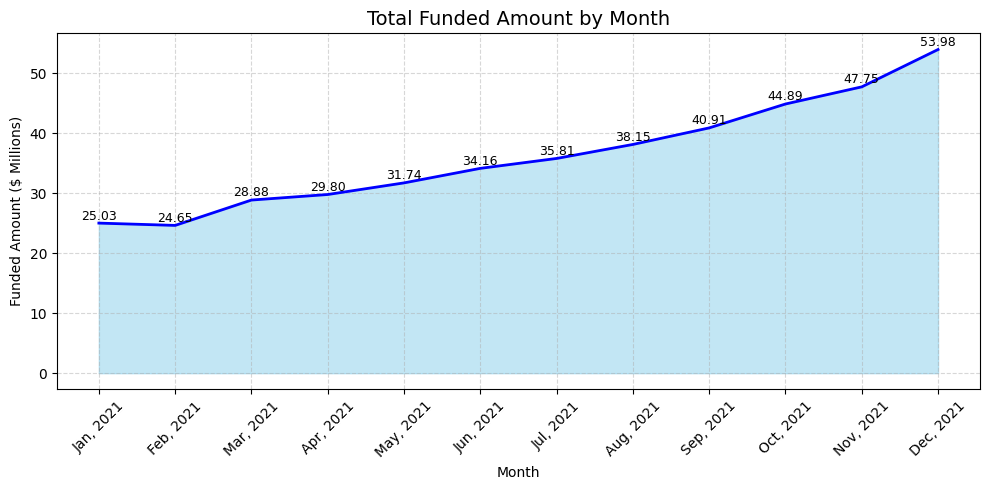

In [18]:
from matplotlib.lines import lineStyles
#create a montly funded column
monthly_funded=(
    df.sort_values('issue_date')
    # sort df in ascending order
    .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b, %Y'))
    .groupby('month_name',sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_millions')
)
plt.figure(figsize=(10,5))
plt.fill_between(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='skyblue',alpha=0.5 # for transparance
)
# plot the line chart
plt.plot(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='blue',linewidth=2
)
#add text labels for each data point
for i,row in monthly_funded.iterrows():
  plt.text(
      i,row['loan_amount_millions']+0.1, # silghtly ablove the point(5.20*)
      f'{row['loan_amount_millions']:.2f}',
      ha='center', va='bottom', fontsize=9, color='black'
  )
  plt.title('Total Funded Amount by Month', fontsize=14)
   # label x-axis
  plt.xlabel('Month')
  #y-axis
  plt.ylabel('Funded Amount ($ Millions)')
  # set x-axis ticks and rotate label for better readable
  plt.xticks(
      ticks=range(len(monthly_funded)),
      labels=monthly_funded['month_name'],
      rotation=45
  )
plt.grid(True ,linestyle ='--',alpha=0.5)
plt.tight_layout()
plt.show()


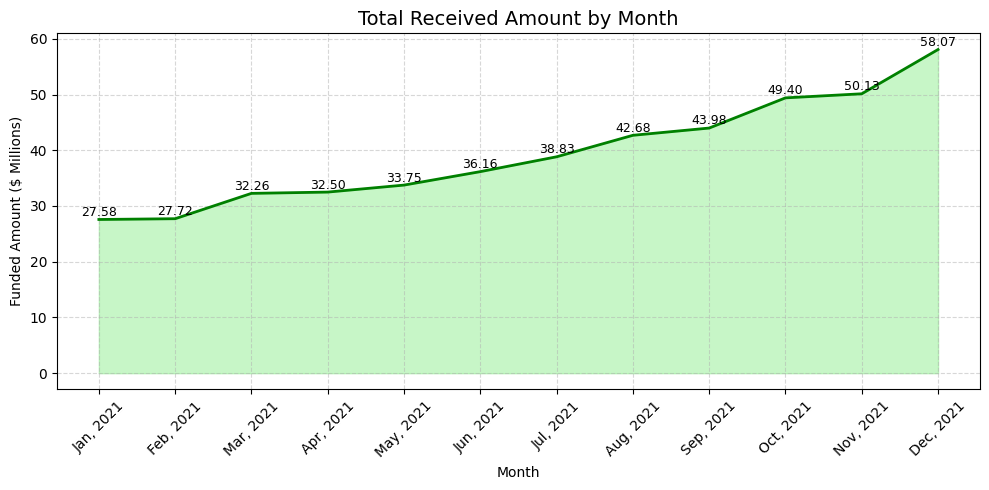

In [19]:
from matplotlib.lines import lineStyles
#create a montly funded column
monthly_funded=(
    df.sort_values('issue_date')
    # sort df in ascending order
    .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b, %Y'))
    .groupby('month_name',sort=False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_millions')
)
plt.figure(figsize=(10,5))
plt.fill_between(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='lightgreen',alpha=0.5 # for transparance
)
# plot the line chart
plt.plot(
    monthly_funded['month_name'],
    monthly_funded['loan_amount_millions'],
    color='green',linewidth=2
)
#add text labels for each data point
for i,row in monthly_funded.iterrows():
  plt.text(
      i,row['loan_amount_millions']+0.1, # silghtly ablove the point(5.20*)
      f'{row['loan_amount_millions']:.2f}',
      ha='center', va='bottom', fontsize=9, color='black'
  )
  plt.title('Total Received Amount by Month', fontsize=14)
   # label x-axis
  plt.xlabel('Month')
  #y-axis
  plt.ylabel('Funded Amount ($ Millions)')
  # set x-axis ticks and rotate label for better readable
  plt.xticks(
      ticks=range(len(monthly_funded)),
      labels=monthly_funded['month_name'],
      rotation=45
  )
plt.grid(True ,linestyle ='--',alpha=0.5)
plt.tight_layout()
plt.show()


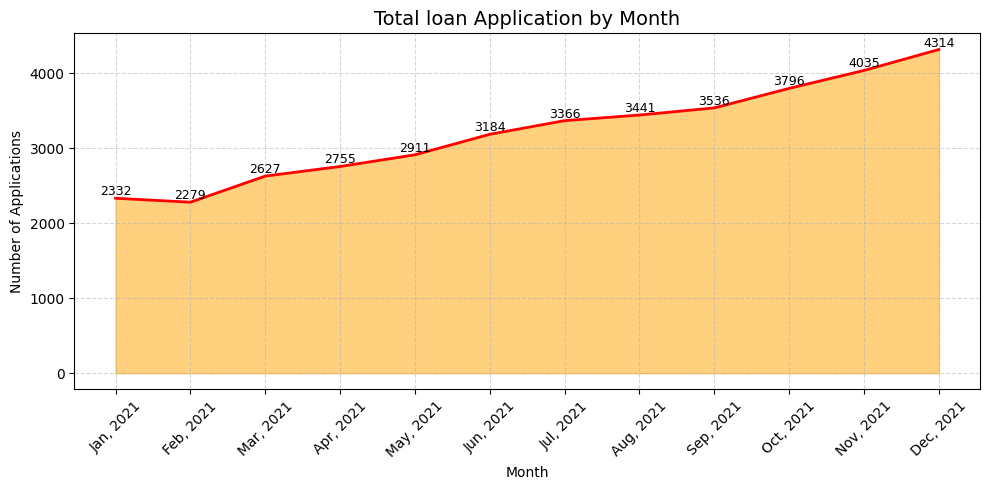

In [20]:
from matplotlib.lines import lineStyles
import pandas as pd
#create a montly funded column
monthly_applications=(
    df.sort_values('issue_date')
    # sort df in ascending order
    .assign(month_name=lambda x:x['issue_date'].dt.strftime('%b, %Y'))
    .groupby('month_name',sort=False)['id']
    .count()
    .reset_index(name='loan_applications_count')
)
plt.figure(figsize=(10,5))
plt.fill_between(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='orange',alpha=0.5 # for transparance
)
# plot the line chart
plt.plot(
    monthly_applications['month_name'],
    monthly_applications['loan_applications_count'],
    color='red',linewidth=2
)
#add text labels for each data point
for i,row in monthly_applications.iterrows():
  plt.text(
      i,row['loan_applications_count']+0.1, # silghtly ablove the point(5.20*)
      f'{row['loan_applications_count']:.0f}',
      ha='center', va='bottom', fontsize=9, color='black'
  )
  plt.title('Total loan Application by Month', fontsize=14)
   # label x-axis
  plt.xlabel('Month')
  #y-axis
  plt.ylabel('Number of Applications')
  # set x-axis ticks and rotate label for better readable
  plt.xticks(
      ticks=range(len(monthly_applications)),
      labels=monthly_applications['month_name'],
      rotation=45
  )
plt.grid(True ,linestyle ='--',alpha=0.5)
plt.tight_layout()
plt.show()


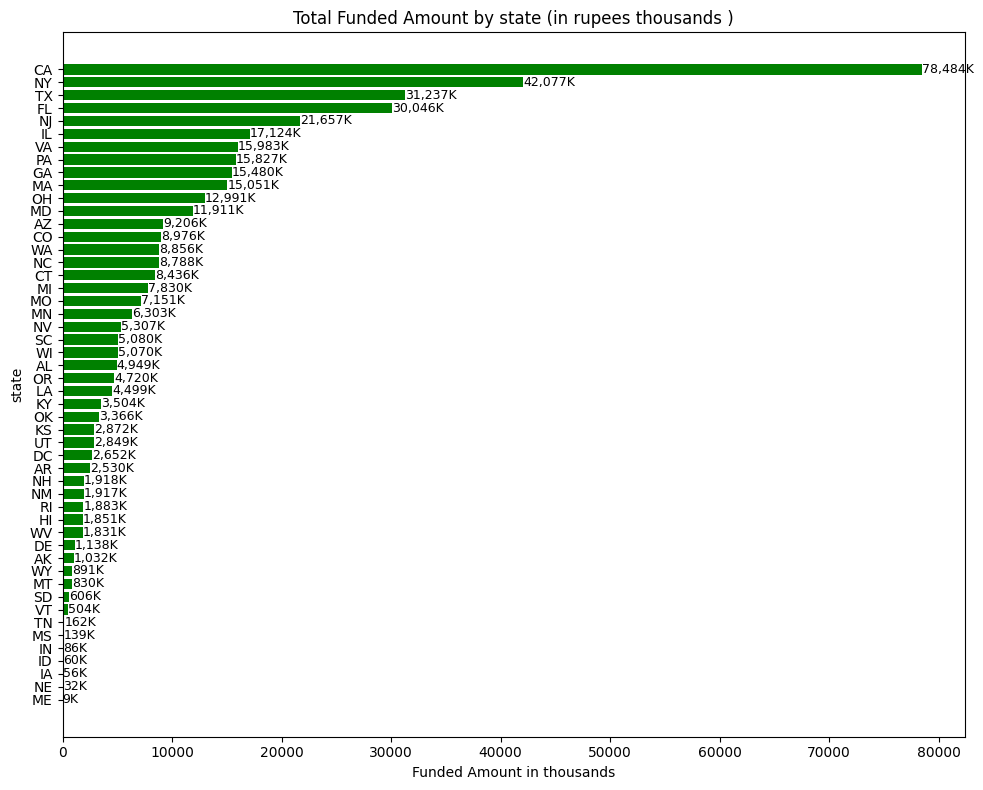

In [21]:
# Group addredd_state and loan_amount
state_funding=df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
# convert loan amounts to thousands
state_funding_thousands=state_funding/1000
# figsize
plt.figure(figsize=(10,8))
bars=plt.barh(state_funding_thousands.index,state_funding_thousands.values,color='green')
# loop through charts to add data labels
for bar in bars:
  width=bar.get_width()
  plt.text(width+10,bar.get_y()+bar.get_height()/2,
           f'{width:,.0f}K',va='center',fontsize=9)

plt.title('Total Funded Amount by state (in rupees thousands )')
plt.xlabel('Funded Amount in thousands')
plt.ylabel('state')
plt.tight_layout()
plt.show()

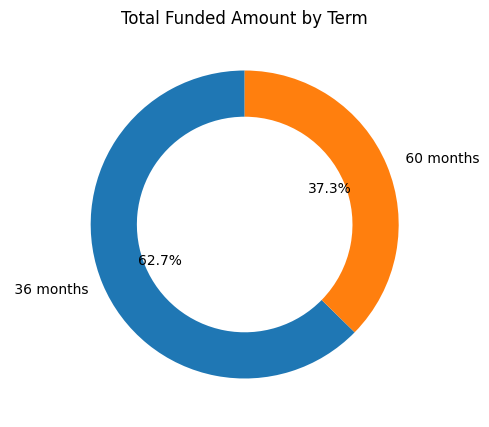

In [22]:
# total fund in millions
term_funding=df.groupby('term')['loan_amount'].sum()/1000000
#create bar chart
plt.figure(figsize=(5,5))
#create donut chart
plt.pie(
    term_funding,
    labels=term_funding.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width':0.3}
)
# add title
plt.title('Total Funded Amount by Term')
plt.show()

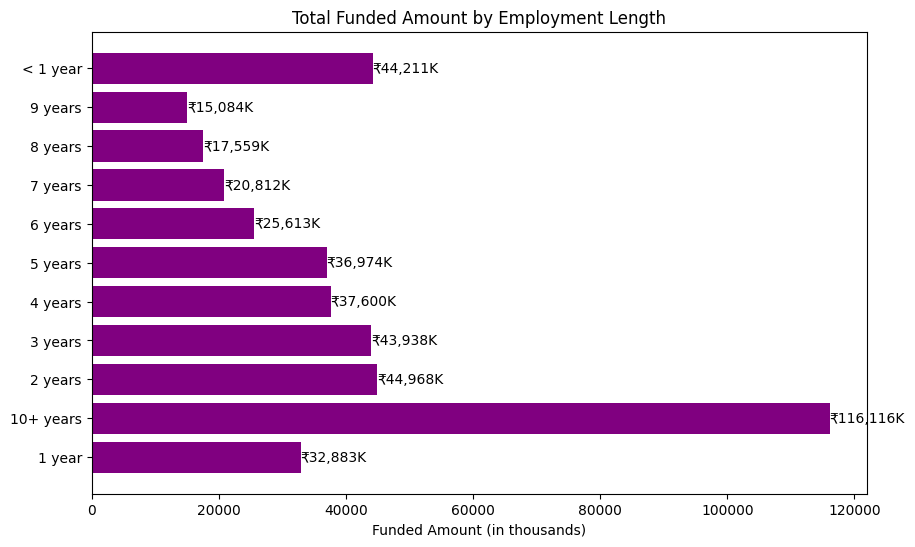

In [23]:
# Employee length by total funded amount
emp_funding=df.groupby('emp_length')['loan_amount'].sum()/1000
plt.figure(figsize=(10,6))
bars=plt.barh(emp_funding.index,emp_funding,color='purple')
for bar in bars:
  width=bar.get_width()
  plt.text(
      width+5,
      bar.get_y()+bar.get_height()/2,
      f'\u20B9{width:,.0f}K',
      va='center'
  )
  #add labels
plt.xlabel('Funded Amount (in thousands)')
plt.title('Total Funded Amount by Employment Length')
plt.show()

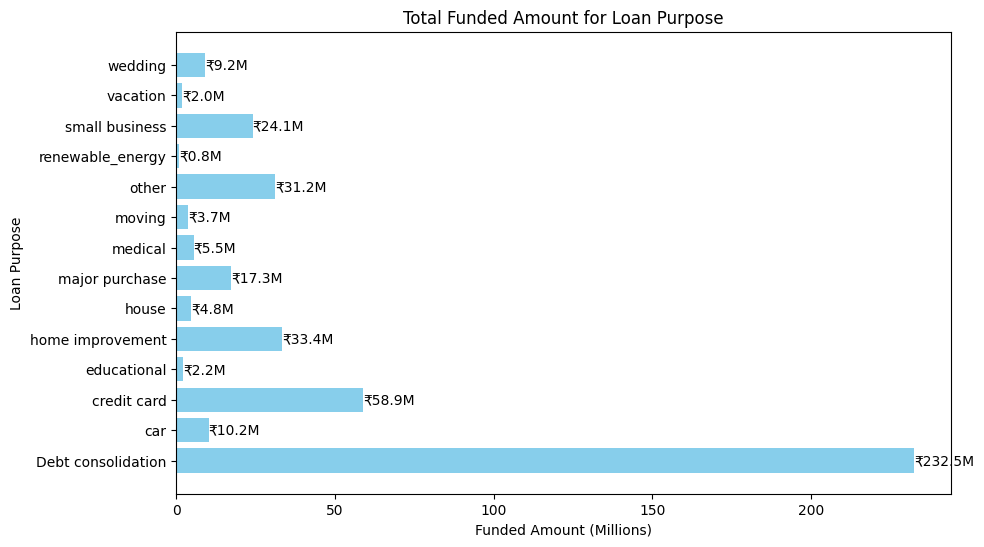

In [24]:
purpose_funding=df.groupby('purpose')['loan_amount'].sum()/1000000
plt.figure(figsize=(10,6))
bars=plt.barh(purpose_funding.index,purpose_funding.values,color='skyblue')
for bar in bars:
  plt.text(
      bar.get_width(),
      bar.get_y()+bar.get_height()/2,
      f'\u20B9{bar.get_width():.1f}M',
      va='center'
  )
  #add labels
plt.xlabel('Funded Amount (Millions)')
plt.ylabel('Loan Purpose')
plt.title('Total Funded Amount for Loan Purpose')
plt.show()